# Data Science/AI Assignment

**Group name:** Send Help

**Student names & numbers:**
* [Xue] - [100193]
* [Shaiza] - [99918]
* [Sas] - [101990]
* [Roos] - [101484]

---

## 1. Setup

**Import libraries**

In [238]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set the display format
pd.set_option('display.float_format', '{:.4f}'.format)

**Load dataset(s)**

In [239]:
# CODE CELL: import the necessary dataset(s) for this iteration
df_observation = pd.read_csv("./data/Dicentrarchus labrax.csv", low_memory=False)
df_habitats = pd.read_csv("./data/habitats_cbs_2022.csv")
df_water = pd.read_csv("./data/haringvliet_salinity_temp_daily_2010_2025.csv")

## 2. Data Understanding
**Data exploration**

In [240]:
# convert salinity
df_water[['salinity_mean']] = df_water[['salinity_mean']] / 1000

In [241]:
df_observation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  object 
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Dicentrarchus labrax       object 
dtypes: float64(3), int64(1), object(2)
memory usage: 574.9+ MB


In [242]:
df_habitats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2179 entries, 0 to 2178
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   decimalLongitude  2179 non-null   float64
 1   decimalLatitude   2179 non-null   float64
 2   agricultural      2179 non-null   float64
 3   built             2179 non-null   float64
 4   coast             2179 non-null   float64
 5   forest            2179 non-null   float64
 6   other             2179 non-null   float64
 7   sand/heather      2179 non-null   float64
 8   water             2179 non-null   float64
 9   wetland           2179 non-null   float64
 10  main_habitat      2179 non-null   object 
dtypes: float64(10), object(1)
memory usage: 187.4+ KB


In [243]:
df_water.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              5844 non-null   object 
 1   salinity_mean     4667 non-null   float64
 2   temperature_mean  5308 non-null   float64
dtypes: float64(2), object(1)
memory usage: 137.1+ KB


In [244]:
df_observation.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,12558786.0000,12558786.0000,12558785.0000,12558786.0000
mean,52.2299,5.5329,8.1428,0.0897
std,0.6647,0.8780,62.6530,2.5155
min,3.5000,3.3500,0.0000,0.0000
25%,51.7000,4.9000,0.0000,0.0000
50%,52.2000,5.6500,1.0000,0.0000
75%,52.8000,6.2000,6.0000,0.0000
max,53.5000,53.4000,100040.0000,1011.0000


In [245]:
df_habitats.describe()

,decimalLongitude,decimalLatitude,agricultural,built,coast,forest,other,sand/heather,water,wetland
count,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000
mean,5.5106,52.2423,9.5712,2.6007,1.5103,1.8161,1.7169,0.4050,1.4614,0.4145
std,0.8900,0.6648,5.3030,3.0534,4.4434,3.0408,2.3667,2.2456,3.4029,2.0897
min,3.3500,50.7500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,4.8500,51.7000,5.3942,0.7801,0.0000,0.1532,0.7353,0.0000,0.1028,0.0000
50%,5.6500,52.2000,10.6239,1.5843,0.0000,0.7351,1.2135,0.0000,0.3183,0.0193
75%,6.1500,52.8000,13.8830,3.3914,0.0000,2.1239,2.0425,0.0270,1.0962,0.1578
max,7.2000,53.5000,29.5228,29.8350,28.9820,28.0752,29.9060,29.4085,29.8636,28.8475


In [246]:
df_water.describe()

,salinity_mean,temperature_mean
count,4667.0000,5308.0000
mean,30.6062,12.4467
std,1.7164,5.0749
min,11.6860,2.8965
25%,29.7366,7.6607
50%,30.7831,12.0286
75%,31.7217,17.3096
max,35.3351,22.2420


In [247]:
print(df_water['salinity_mean'].describe())

count   4667.0000
mean      30.6062
std        1.7164
min       11.6860
25%       29.7366
50%       30.7831
75%       31.7217
max       35.3351
Name: salinity_mean, dtype: float64


---

## 3. Data Preparation

**Merge**


In [248]:
# Convert the 'eventDate' column in the observation dataset to datetime format
df_observation['eventDate'] = pd.to_datetime(df_observation['eventDate'])

# Merge the observation and habitat datasets on the latitude and longitude columns
df_obs_habitat = pd.merge(
    df_observation, 
    df_habitats, 
    on=['decimalLatitude', 'decimalLongitude'], 
    how='left'
)

# Convert the 'eventDate' column in the merged dataset to datetime format and the 'date' column in the water dataset to datetime format
df_obs_habitat['eventDate'] = pd.to_datetime(df_obs_habitat['eventDate'])

# Convert the 'date' column in the water dataset to datetime format and remove timezone information
df_water['date'] = pd.to_datetime(df_water['date']).dt.tz_localize(None)

# Merge the observation-habitat dataset with the water dataset on the 'eventDate' and 'date' columns
df_obs_habitat_water = df_obs_habitat.merge(
    df_water,
    left_on='eventDate',
    right_on='date',
    how='left'
)

# Drop the 'date' column from the merged dataset
df_obs_habitat_water.drop(columns=['date'], inplace=True)

# Convert the 'Dicentrarchus labrax' column to numeric
df_obs_habitat_water['Dicentrarchus labrax'] = pd.to_numeric(df_obs_habitat_water['Dicentrarchus labrax'], errors='coerce')
df_obs_habitat_water.sample(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Dicentrarchus labrax,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,salinity_mean,temperature_mean
1835310,51.4500,6.1000,2010-10-22,0.0000,0,0.0000,10.0368,1.7985,0.0000,5.6471,1.1431,0.5582,0.0914,0.0475,agricultural,31.3482,12.4920
11004090,53.1000,5.9500,2025-07-23,46.0000,0,0.0000,12.6839,0.7946,0.0000,0.4994,1.3303,0.0015,1.5520,1.7639,agricultural,31.5723,21.0059
5601145,52.1000,5.2000,2017-02-06,0.0000,0,0.0000,0.9187,6.0641,0.0000,7.0974,4.5747,0.3382,0.0459,0.0117,forest,31.8950,5.2997
5037339,52.0000,5.5500,2025-06-26,19.0000,0,0.0000,6.1695,8.7355,0.0000,0.1547,2.8933,0.0000,0.5981,0.5384,built,31.1763,19.2017
10358841,52.9500,6.9500,2018-12-18,2.0000,0,0.0000,7.4301,6.6123,0.0000,0.9291,3.0826,0.0000,0.6358,0.0000,agricultural,31.7555,6.3653


**Cleaning**

In [249]:
# 1. Inspect missing values 
df_missing_obs_habitat = df_obs_habitat[df_obs_habitat.isnull().any(axis=1)]
df_missing_obs_habitat.sample(5)

df_missing = df_obs_habitat_water[df_obs_habitat_water.isnull().any(axis=1)]
df_missing.sample(5)

print(f"Missing value counts: {df_obs_habitat_water.isnull().sum().sum()}")

Missing value counts: 3681572


In [250]:
# 2. Drop rows where habitat info is missing (geographic join failure)
habitat_cols = ['agricultural', 'built', 'coast', 'forest', 'other',
                'sand/heather', 'water', 'wetland']

df_no_missing = df_obs_habitat_water.dropna(subset=habitat_cols)


# 3. Sort by date before interpolation
df_no_missing = df_no_missing.copy()
df_no_missing = df_no_missing.sort_values('eventDate').reset_index(drop=True)

# 4. Short gaps (≤14 days): linear interpolation
df_no_missing['salinity_mean'] = (
    df_no_missing['salinity_mean']
    .interpolate(method='linear', limit=14)
)
df_no_missing['temperature_mean'] = (
    df_no_missing['temperature_mean']
    .interpolate(method='linear', limit=14)
)

# 5. Longer gaps (>14 days): fill with historical seasonal mean
df_no_missing['doy'] = pd.to_datetime(df_no_missing['eventDate']).dt.dayofyear
seasonal_sal  = df_no_missing.groupby('doy')['salinity_mean'].transform('mean')
seasonal_temp = df_no_missing.groupby('doy')['temperature_mean'].transform('mean')

df_no_missing['salinity_mean']    = df_no_missing['salinity_mean'].fillna(seasonal_sal)
df_no_missing['temperature_mean'] = df_no_missing['temperature_mean'].fillna(seasonal_temp)

df_no_missing = df_no_missing.drop(columns='doy')

# 6. Verify 
print(f"Remaining missing values after processing: {df_no_missing.isnull().sum()}")

Remaining missing values after processing: decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Dicentrarchus labrax         0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
salinity_mean                0
temperature_mean             0
dtype: int64


In [251]:
df_clean = df_no_missing.copy()

**Visualization**

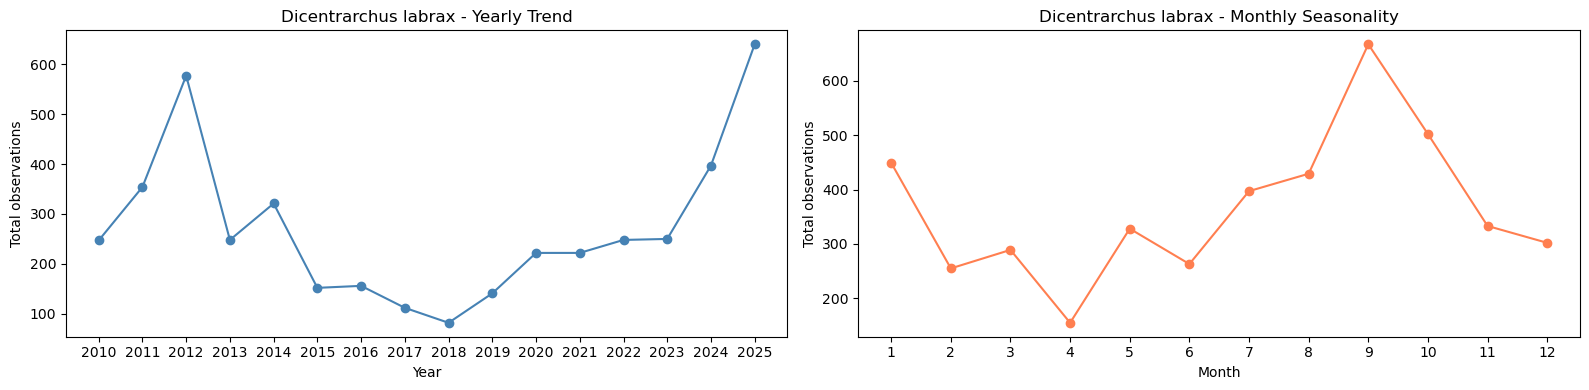

In [252]:
df_visual = df_clean.copy()  

# extract year and month from eventDate for visualization
df_visual['year'] = df_visual['eventDate'].dt.year
df_visual['month'] = df_visual['eventDate'].dt.month

present_mask = df_visual['Dicentrarchus labrax'] > 0
absent_mask  = df_visual['Dicentrarchus labrax'] == 0

#Year
yearly_species = (
    df_visual.groupby('year')['Dicentrarchus labrax']
    .sum()
    .sort_index()
)

# Month seasonality 
monthly_species = (
    df_visual.groupby('month')['Dicentrarchus labrax']
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# left
yearly_species.plot(
    ax=axes[0],
    marker='o',
    color='steelblue'
)

axes[0].set_title('Dicentrarchus labrax - Yearly Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total observations')

# display all years on x-axis with rotation
axes[0].set_xticks(yearly_species.index)

# right
monthly_species.plot(
    ax=axes[1],
    marker='o',
    color='coral'
)

axes[1].set_title('Dicentrarchus labrax - Monthly Seasonality')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total observations')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

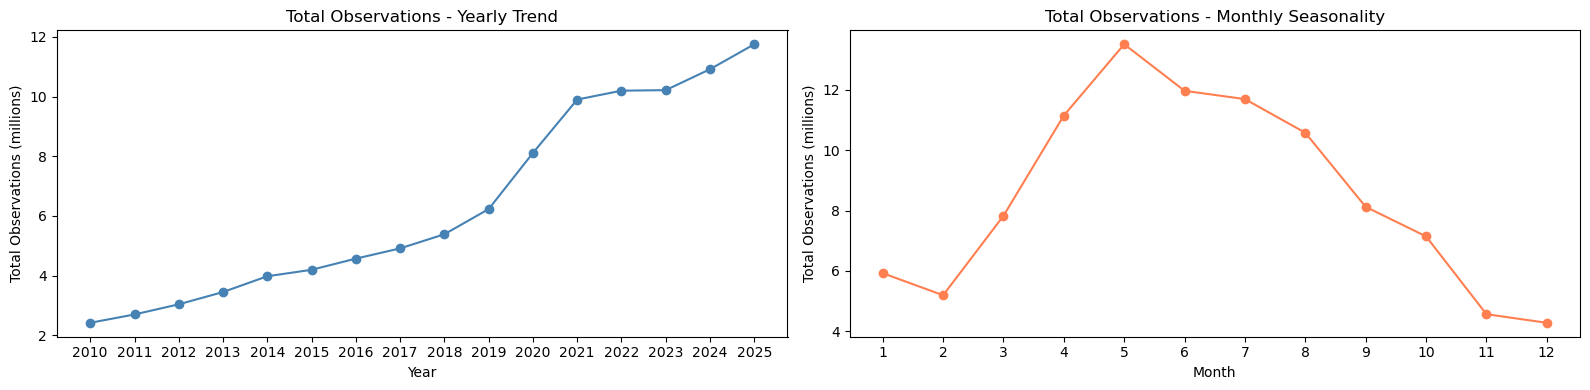

In [253]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

#  Yearly 
yearly_total_observations = (
    df_visual.groupby('year')['total_observations']
    .sum()
    .sort_index()
)

(yearly_total_observations / 1e6).plot(
    ax=axes[0],
    marker='o',
    color='steelblue'
)

axes[0].set_title('Total Observations - Yearly Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Observations (millions)')
axes[0].set_xticks(yearly_total_observations.index)


# Monthly 
monthly_total_observations = (
    df_visual.groupby(df_visual['eventDate'].dt.month)['total_observations']
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

(monthly_total_observations / 1e6).plot(
    ax=axes[1],
    marker='o',
    color='coral'
)

axes[1].set_title('Total Observations - Monthly Seasonality')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Observations (millions)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

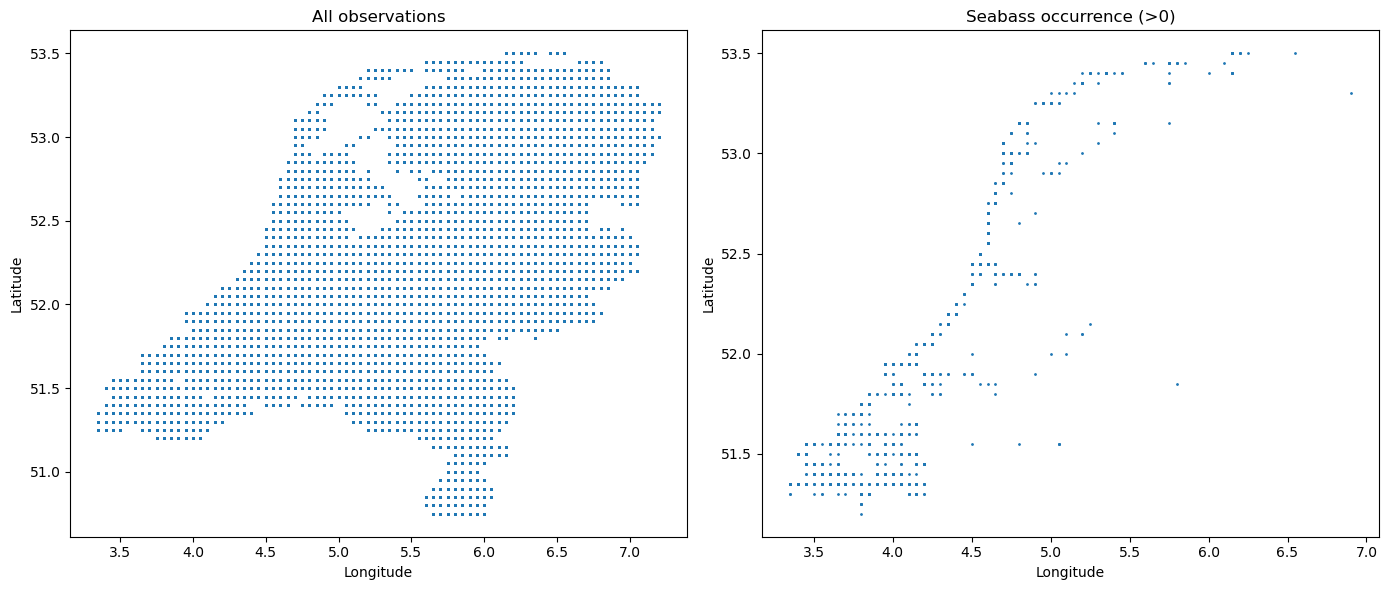

In [254]:
# Display the distribution of all observations and seabass occurrences
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left
axes[0].scatter(
    df_visual['decimalLongitude'],
    df_visual['decimalLatitude'],
    s=1
)
axes[0].set_title("All observations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# right
df_seabass = df_visual[present_mask]

axes[1].scatter(
    df_seabass['decimalLongitude'],
    df_seabass['decimalLatitude'],
    s=1
)
axes[1].set_title("Seabass occurrence (>0)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

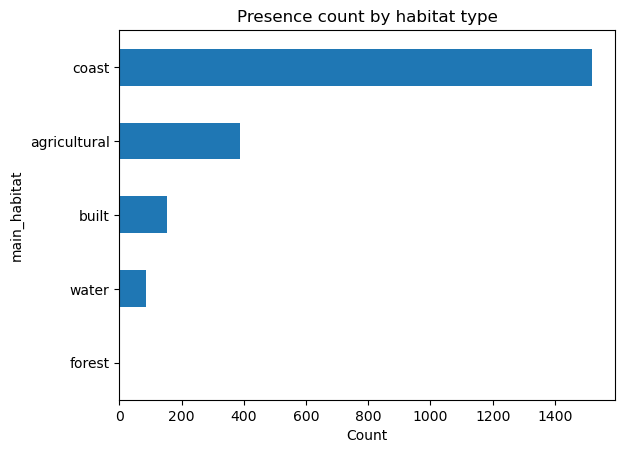

In [255]:
# Display the presence count by habitat type
df_visual[present_mask].groupby('main_habitat')['Dicentrarchus labrax'].count().sort_values().plot(kind='barh')
plt.xlabel('Count')
plt.title('Presence count by habitat type')
plt.show()

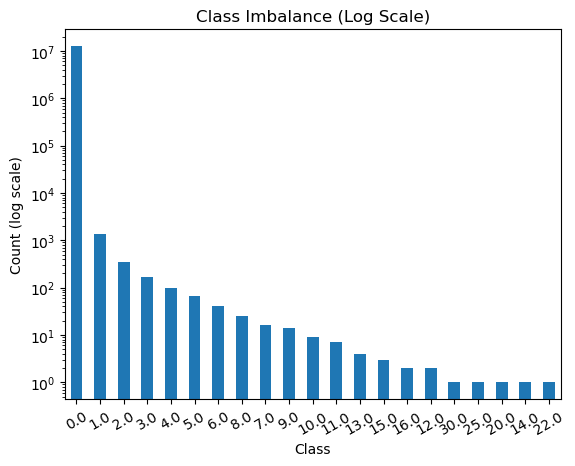

In [256]:
counts = df_clean['Dicentrarchus labrax'].value_counts()

plt.figure()
counts.plot(kind='bar')

plt.yscale('log')

plt.title("Class Imbalance (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=30)

plt.show()

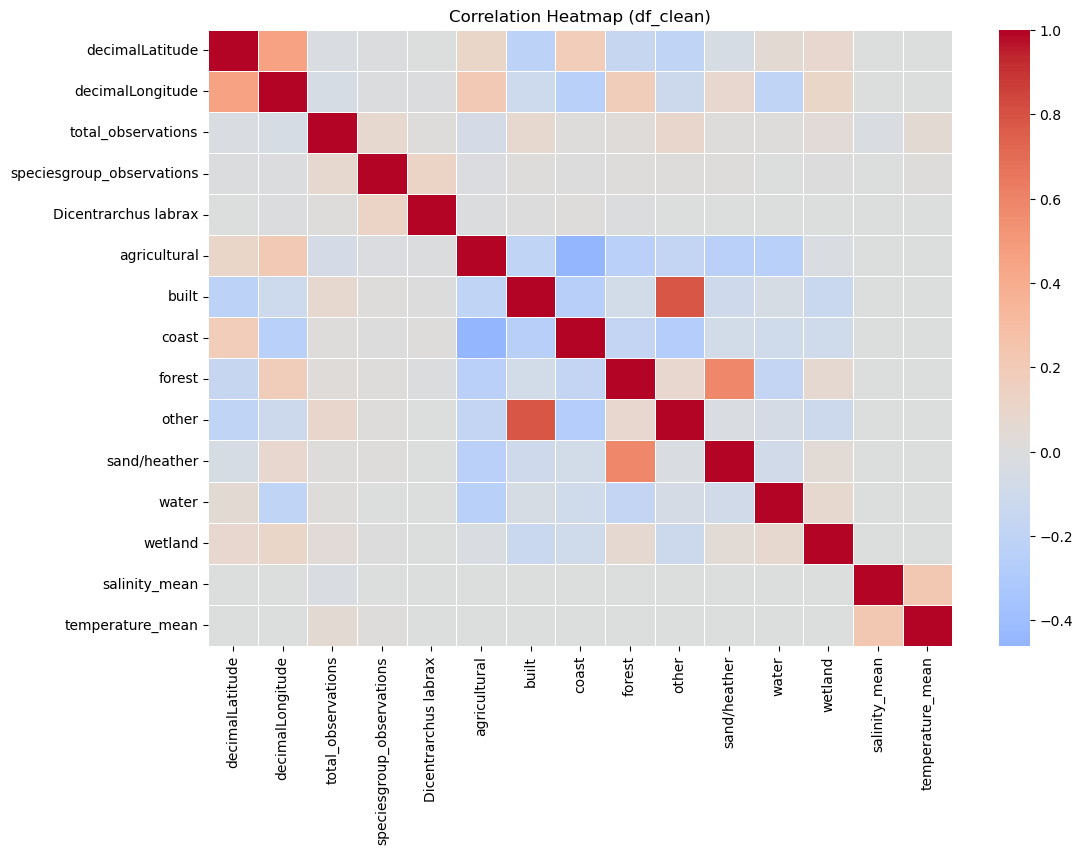

In [257]:
# Display the correlation heatmap for numeric columns in df_clean
df_num = df_clean.select_dtypes(include=['number'])

corr = df_num.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap (df_clean)")
plt.show()

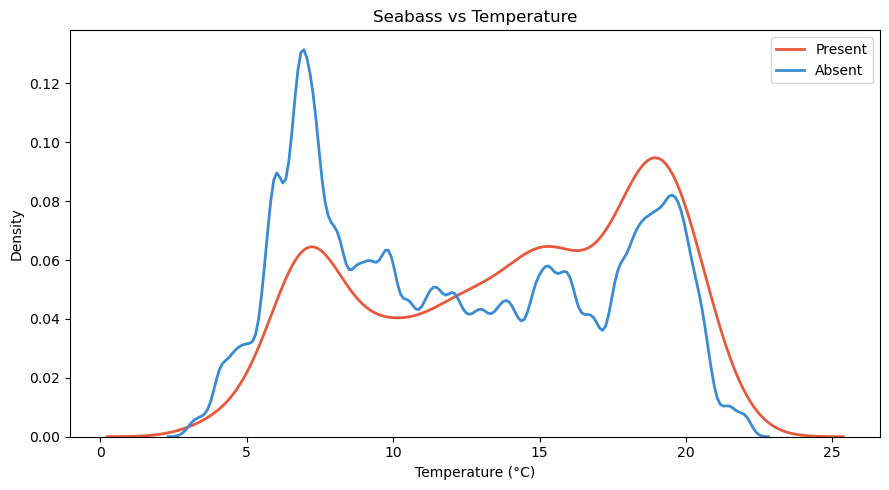

In [258]:
present = df_visual[present_mask]['temperature_mean'].dropna()
absent  = df_visual[absent_mask]['temperature_mean'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(present, ax=ax, color='#E8593C', linewidth=2, label='Present')
sns.kdeplot(absent,  ax=ax, color='#3B8BD4', linewidth=2, label='Absent')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Seabass vs Temperature')
ax.legend()

plt.tight_layout()
plt.show()

**Feature Engineering & Target Definition**

In [259]:
# DATA AGGREGATION
# Extract temporal features
df_aggregated = df_clean.copy()
df_plot = df_aggregated.copy()
df_aggregated['year'] = df_aggregated['eventDate'].dt.year
df_aggregated['month'] = df_aggregated['eventDate'].dt.month
df_aggregated['season'] = df_aggregated['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# Aggregate data by spatial grid (lat/lon) and time (year + season)
df_agg = df_aggregated.groupby(
    ['decimalLatitude', 'decimalLongitude', 'year', 'season']
).agg({
    'Dicentrarchus labrax': 'sum',
    'total_observations': 'mean',
    'speciesgroup_observations': 'mean',
    'salinity_mean': 'mean',
    'temperature_mean': 'mean',
    'agricultural': 'first',
    'built': 'first',
    'coast': 'first',
    'forest': 'first',
    'other': 'first',
    'sand/heather': 'first',
    'water': 'first',
    'wetland': 'first',
}).reset_index()

# Create binary target variable (species presence/absence)
df_agg['presence'] = (df_agg['Dicentrarchus labrax'] > 0).astype(int)

# One-hot season
df_agg = pd.get_dummies(df_agg, columns=['season'], prefix='season', drop_first=True)

# Define feature set
season_cols = [col for col in df_agg.columns if col.startswith('season_')]

features = [
    'total_observations',
    'speciesgroup_observations',
    'year',
] + season_cols + [
    'agricultural', 'built', 'coast', 'forest',
    'other', 'sand/heather', 'water', 'wetland',
    'salinity_mean', 'temperature_mean',
]

X = df_agg[features]
y = df_agg['presence']

print("="*60)
print("DATA AGGREGATION COMPLETE")
print("="*60)
print(f"X shape: {X.shape}")
print(f"Features: {len(features)}")
print(f"Presence ratio: {y.sum()/len(y)*100:.2f}%")
print(f"Y value counts:\n{y.value_counts()}")


DATA AGGREGATION COMPLETE
X shape: (137536, 16)
Features: 16
Presence ratio: 0.82%
Y value counts:
presence
0    136411
1      1125
Name: count, dtype: int64


        total_observations  Dicentrarchus labrax  relative_abundance
season                                                              
Spring             10.2722              772.0000           7515.4288
Summer             10.8274             1089.0000          10057.7739
Fall                6.3369             1502.0000          23702.4021
Winter              4.9594             1006.0000          20284.8290


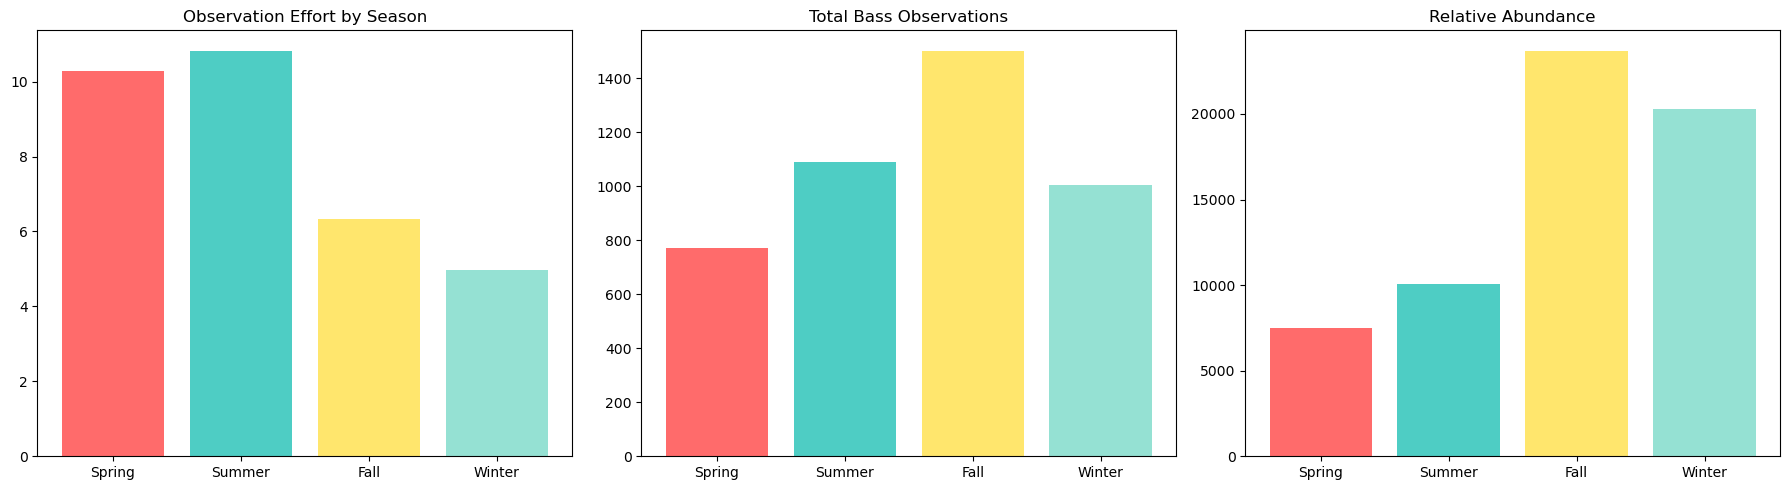

In [260]:
# Step 1: Prepare Plot Data

season_order = ['Spring', 'Summer', 'Fall', 'Winter']

df_plot = df_aggregated.copy()

seasonal_data = df_plot.groupby('season').agg({
    'total_observations': 'mean',
    'Dicentrarchus labrax': 'sum',
}).reindex(season_order)

# avoid division by zero
seasonal_data['relative_abundance'] = (
    seasonal_data['Dicentrarchus labrax'] /
    seasonal_data['total_observations'].replace(0, np.nan) * 100
)

print(seasonal_data)

# Step 2: Plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3']

# Plot 1
axes[0].bar(season_order, seasonal_data['total_observations'], color=colors)
axes[0].set_title("Observation Effort by Season")

# Plot 2
axes[1].bar(season_order, seasonal_data['Dicentrarchus labrax'], color=colors)
axes[1].set_title("Total Bass Observations")

# Plot 3
axes[2].bar(season_order, seasonal_data['relative_abundance'], color=colors)
axes[2].set_title("Relative Abundance")

plt.tight_layout()
plt.show()

In [261]:
train_mask = (df_agg['year'] < 2024).values
test_mask = (df_agg['year'] >= 2024).values

X_train = X[train_mask]
y_train = y[train_mask]
X_test = X[test_mask]
y_test = y[test_mask]

print(f"Train (year < 2024): {len(X_train)}, positive: {y_train.sum()}")
print(f"Test (year >= 2024): {len(X_test)}, positive: {y_test.sum()}")


Train (year < 2024): 120344, positive: 902
Test (year >= 2024): 17192, positive: 223


## 4. Modeling

Three modelling iterations are performed:
- **Iteration 1** – Baseline Random Forest with default 0.5 threshold
- **Iteration 2** – Same RF, threshold optimised to maximise F1 on the test set
- **Iteration 3** – XGBoost with scale_pos_weight, threshold chosen to maximise F1

Before training these models, a DummyClassifier is used as a baseline. The DummyClassifier always predicts the majority class, making it possible to check whether the machine learning models perform better than a simple rule-based approach.

**Dummy Baseline** – Majority-class classifier 

In [262]:
# Always predicting the majority class is the simplest possible strategy.
# Any real model should clearly outperform it.
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"{'Dummy Baseline (most_frequent)':-^60}")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

---------------Dummy Baseline (most_frequent)---------------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     16969
           1       0.00      0.00      0.00       223

    accuracy                           0.99     17192
   macro avg       0.49      0.50      0.50     17192
weighted avg       0.97      0.99      0.98     17192



**Iteration 1** – Baseline Random Forest (default threshold = 0.5)

In [263]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, roc_auc_score

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight={0: 1, 1: 10},
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\n" + "="*60)
print("Random Forest Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16969
           1       0.39      0.44      0.41       223

    accuracy                           0.98     17192
   macro avg       0.69      0.72      0.70     17192
weighted avg       0.98      0.98      0.98     17192



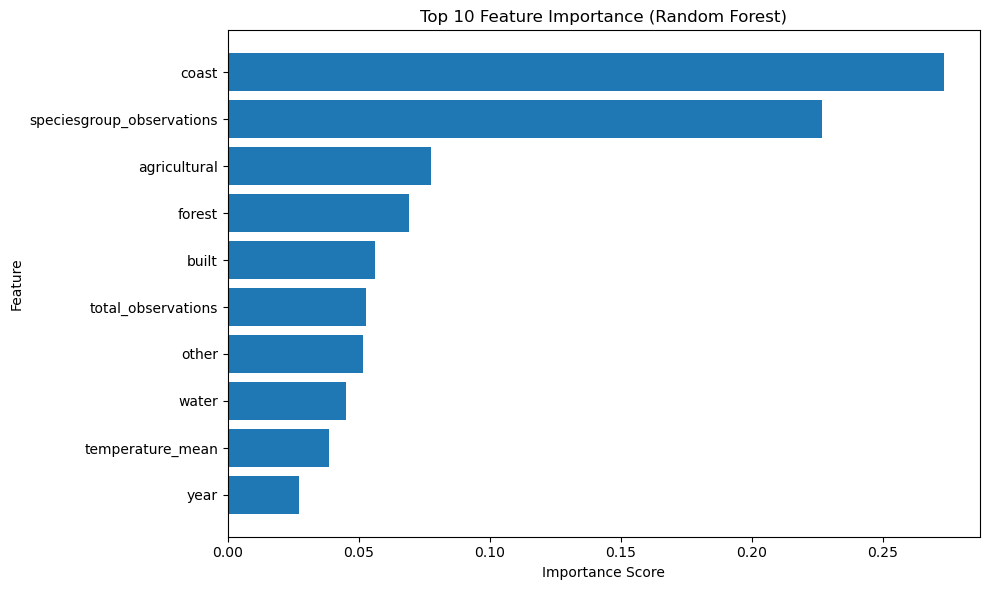

In [264]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Iteration 2** - Random forest model with threshold tuning

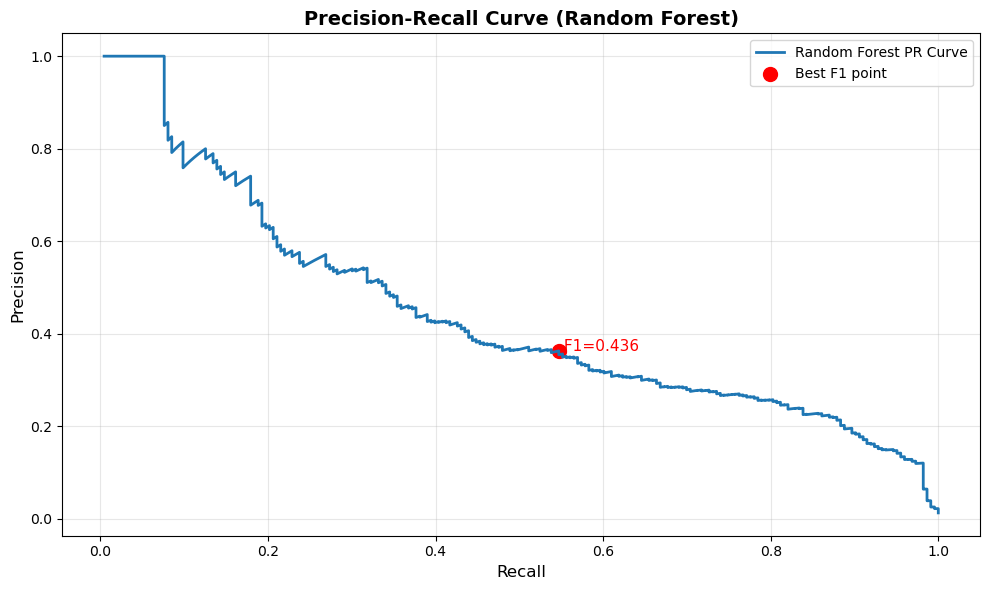

In [265]:
from sklearn.metrics import precision_recall_curve, classification_report, f1_score

y_prob_rf = model.predict_proba(X_test)[:, 1]
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_prob_rf)

precision_rf = precision_rf[:-1]
recall_rf = recall_rf[:-1]

# Find best f1 score
f1_scores = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf + 1e-9)

best_idx = np.argmax(f1_scores)

best_precision = precision_rf[best_idx]
best_recall = recall_rf[best_idx]
best_f1 = f1_scores[best_idx]

# PLOT
plt.figure(figsize=(10, 6))

plt.plot(recall_rf, precision_rf, linewidth=2, label='Random Forest PR Curve')

# best F1 point
plt.scatter(best_recall, best_precision, color='red', s=100, label='Best F1 point')

plt.text(
    best_recall, best_precision,
    f" F1={best_f1:.3f}",
    fontsize=11,
    color='red'
)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve (Random Forest)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [266]:
from sklearn.metrics import classification_report

best_threshold = thresholds_rf[best_idx]
y_pred_best = (y_prob_rf >= best_threshold).astype(int)

print("="*60)
print("Random Forest Classification Report (Best F1):")
print("="*60)
print(classification_report(y_test, y_pred_best))

Random Forest Classification Report (Best F1):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16969
           1       0.36      0.55      0.44       223

    accuracy                           0.98     17192
   macro avg       0.68      0.77      0.71     17192
weighted avg       0.99      0.98      0.98     17192



**Iteration 3** - XGBoost  model with threshold selection

In [267]:
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale, 
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb)}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_xgb)}")

ROC-AUC: 0.967864903740321
PR-AUC:  0.4381833242952676


In [268]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

precision = precision[:-1]
recall = recall[:-1]

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_best = (y_prob_xgb >= best_threshold).astype(int)

print("="*60)
print("XGBoost Classification Report (Best F1):")
print("="*60)
print(classification_report(y_test, y_pred_best))

XGBoost Classification Report (Best F1):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16969
           1       0.45      0.46      0.45       223

    accuracy                           0.99     17192
   macro avg       0.72      0.72      0.72     17192
weighted avg       0.99      0.99      0.99     17192



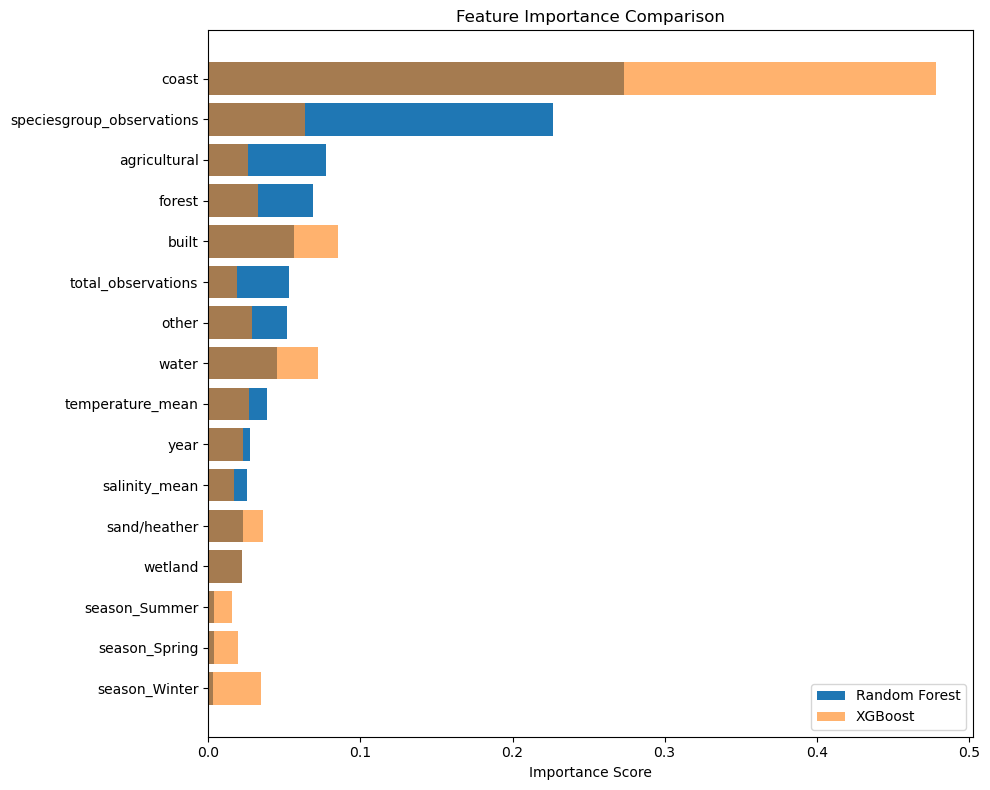

In [269]:
# RF importance
rf_imp = pd.DataFrame({
    'feature': X.columns,
    'rf_importance': model.feature_importances_
})

# XGBoost importance
xgb_imp = pd.DataFrame({
    'feature': X.columns,
    'xgb_importance': xgb.feature_importances_
})

importance_df = rf_imp.merge(xgb_imp, on='feature')
importance_df = importance_df.sort_values('rf_importance', ascending=True)

# plot
plt.figure(figsize=(10, 8))

plt.barh(importance_df['feature'], importance_df['rf_importance'], label='Random Forest')
plt.barh(importance_df['feature'], importance_df['xgb_importance'], alpha=0.6, label='XGBoost')

plt.title("Feature Importance Comparison")
plt.xlabel("Importance Score")
plt.legend()

plt.tight_layout()
plt.show()